In [1]:
import numpy as np
import matplotlib.pyplot as plt


class Cities:
    def __init__(self, n, seed=None):
        if not (isinstance(n, int) and n > 3):
            raise Exception("n needs to be an integer larger than 3")

        if seed is not None:
            np.random.seed(seed)

        self.n = n

        x = np.random.rand(n)
        y = np.random.rand(n)

        self.x, self.y = x, y

    def dist(self, city0, city1):
        x, y = self.x, self.y

        x0, y0 = x[city0], y[city0]
        x1, y1 = x[city1], y[city1]

        return np.sqrt((x1 - x0)**2 + (y1 - y0)**2)

    def __repr__(self) -> str:
        return f"Cities obj with {self.n} cities"


cities = Cities(6, seed=None)
print(cities)
cities.x

Cities obj with 6 cities


array([0.49303621, 0.27968543, 0.12511788, 0.59688503, 0.40795997,
       0.12822759])

In [2]:
cities.y

array([0.82849354, 0.20418351, 0.32473814, 0.57877375, 0.9111091 ,
       0.08356909])

In [3]:
another = Cities(5, seed=42)
another.x

array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864])

In [4]:
another.y

array([0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258])

In [5]:
cities.n

6

In [6]:
def init_config(cities: Cities):
    return np.random.permutation(cities.n)  # route


route = init_config(cities)

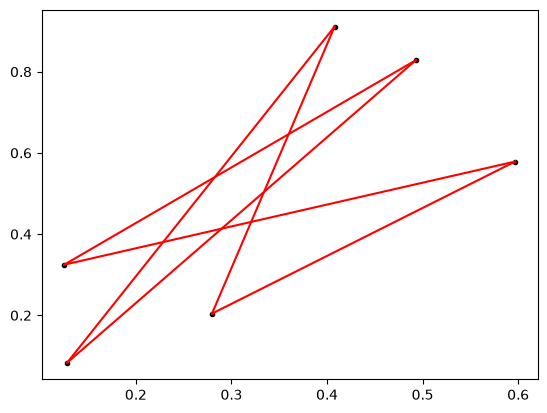

In [7]:
def display(cities, route):
    x, y = cities.x, cities.y

    plt.clf()
    plt.axis("equal")

    plt.plot(x, y, "o", color="black")

    plt.plot(x[route], y[route], color="red")

    comeback = [route[-1], route[0]]

    plt.plot(x[comeback], y[comeback], color="red")

    plt.show()


def display(cities, route):
    x, y, n = cities.x, cities.y, cities.n

    plt.clf()

    plt.plot(x, y, '.', color="black")

    # plt.plot(x[route], y[route], color="red")

    # city0, city1 = route[-1], route[0]

    # plt.plot(
    #     [x[city0], x[city1]],
    #     [y[city0], y[city1]],
    #     color="red"
    # )

    for e in range(n):
        city0 = route[e]
        city1 = route[(e+1) % n]

        plt.plot(
            [x[city0], x[city1]],
            [y[city0], y[city1]],
            color="red"
        )

    plt.pause(0.01)


display(cities, route)

In [8]:
class TSP:
    def __init__(self, n, seed=None):
        if not (isinstance(n, int) and n > 3):
            raise Exception("n needs to be an integer larger than 3")

        if seed is not None:
            np.random.seed(seed)

        self.n = n

        x = np.random.rand(n)
        y = np.random.rand(n)

        self.x, self.y = x, y

    def dist(self, city0, city1):
        x, y = self.x, self.y

        x0, y0 = x[city0], y[city0]
        x1, y1 = x[city1], y[city1]

        return np.sqrt((x1 - x0)**2 + (y1 - y0)**2)

    def __repr__(self) -> str:
        return f"TSP with {self.n} cities"

    def init_config(self):
        return np.random.permutation(self.n)  # route

    def display(self, route):
        x, y, n = self.x, self.y, self.n

        plt.clf()

        plt.plot(x, y, '.', color="black")

        # plt.plot(x[route], y[route], color="red")

        # city0, city1 = route[-1], route[0]

        # plt.plot(
        #     [x[city0], x[city1]],
        #     [y[city0], y[city1]],
        #     color="red"
        # )

        for e in range(n):
            city0 = route[e]
            city1 = route[(e+1) % n]

            plt.plot(
                [x[city0], x[city1]],
                [y[city0], y[city1]],
                color="red"
            )

        plt.pause(0.01)

    def cost(self, route):
        n = self.n

        c = 0.0

        for e in range(n):
            city0 = route[e]
            city1 = route[(e + 1) % n]

            c += self.dist(city0, city1)

        return c

    def delta_cost(self, old_route, new_route):
        c_old = self.cost(old_route)
        c_new = self.cost(new_route)

        return c_new - c_old

    def propose_move(self, route):
        n = len(route)

        while True:
            e1 = np.random.randint(n)
            e2 = np.random.randint(n)

            if e1 > e2:
                e1, e2 = e2, e1

            if e1 != e2 and e1 + 1 != e2 and not (e1 == 0 and e2 == n-1):
                break

        # route[e1+1:e2+1] = route[e1+1:e2+1][::-1]
        new_route = route.copy()
        new_route[e1+1:e2+1] = new_route[e2:e1:-1]
        return new_route

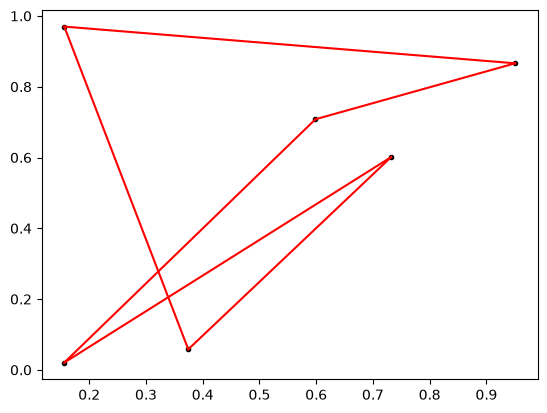

In [9]:
probl = TSP(6, seed=42)
probl.x

probl.y

probl.n

route = probl.init_config()

p1 = TSP(4)
p2 = TSP(8)

r1 = p1.init_config()
r2 = p2.init_config()

r1, r2

probl.dist(0, 2)
probl.cost(route)

probl.display(route)

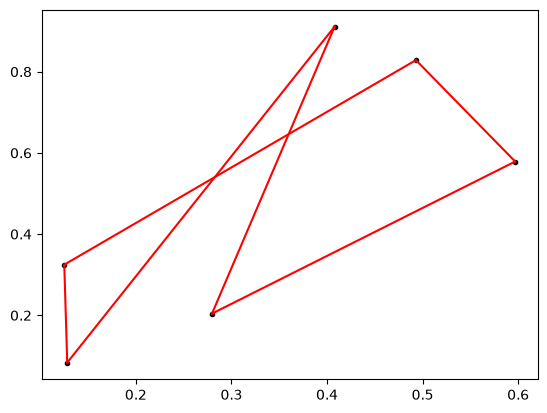

t=0 c=np.float64(3.1032872114471477)
t=2 c=np.float64(2.8362163632137194)
t=5 c=np.float64(2.050331493656567)
t=6 c=np.float64(1.9657191887907455)
final cost c=np.float64(1.9657191887907455)


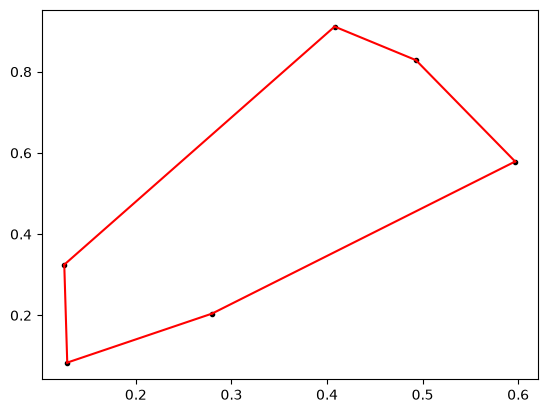

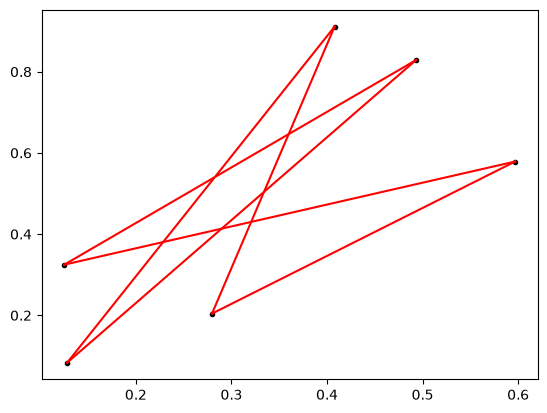

t=1 c=np.float64(2.8362163632137194)
t=2 c=np.float64(2.819349477960909)
t=7 c=np.float64(1.9657191887907453)
final cost c=np.float64(1.9657191887907453)


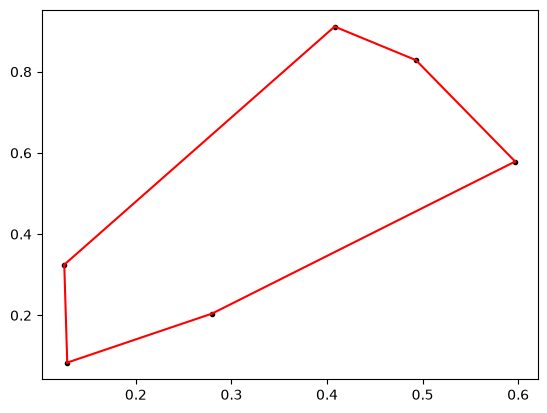

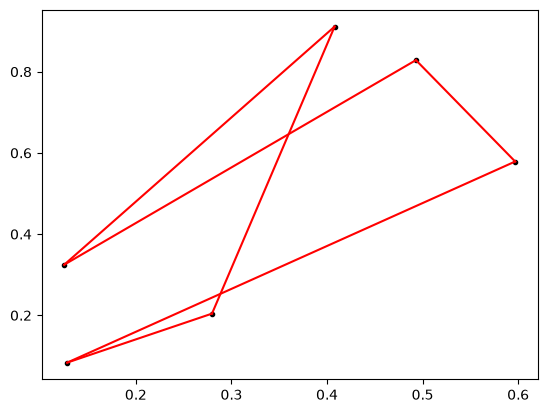

t=3 c=np.float64(3.103287211447148)
final cost c=np.float64(3.103287211447148)


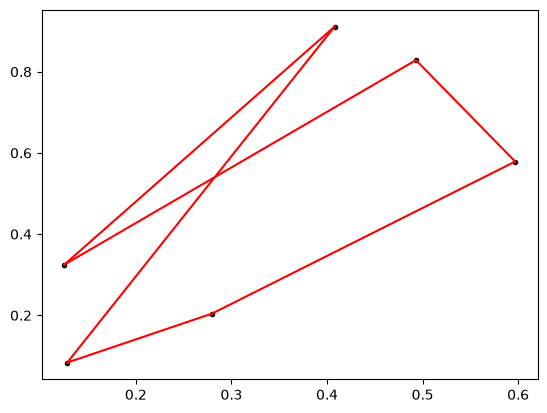

best cost c=1.9657191887907453


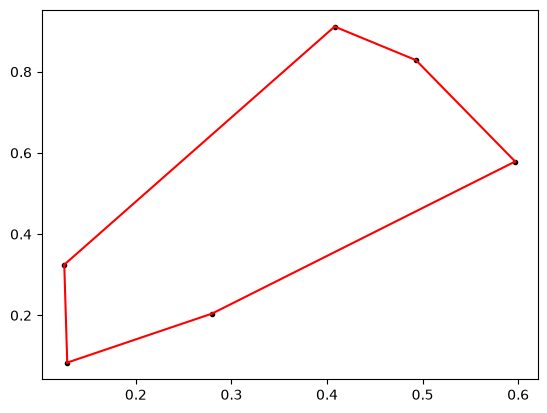

array([3, 1, 5, 2, 4, 0], dtype=int32)

In [10]:
def cost(cities, route):
    n = cities.n

    c = 0.0

    for e in range(n):
        city0 = route[e]
        city1 = route[(e + 1) % n]

        c += cities.dist(city0, city1)

    return c


def delta_cost(cities, old_route, new_route):
    c_old = cost(cities, old_route)
    c_new = cost(cities, new_route)

    return c_new - c_old


def propose_move(route):
    n = len(route)

    while True:
        e1 = np.random.randint(n)
        e2 = np.random.randint(n)

        if e1 > e2:
            e1, e2 = e2, e1

        if e1 != e2 and e1 + 1 != e2 and not (e1 == 0 and e2 == n-1):
            break

    # route[e1+1:e2+1] = route[e1+1:e2+1][::-1]
    new_route = route.copy()
    new_route[e1+1:e2+1] = new_route[e2:e1:-1]
    return new_route


def greedy(cities, max_iters=10, seed=None, restarts=1):
    if seed is not None:
        np.random.seed(seed)

    best_c = np.inf

    best_x = None

    for r in range(restarts):
        x = init_config(cities)
        c = cost(cities, x)

        display(cities, x)

        for t in range(max_iters):
            y = propose_move(x)
            # cnew = cost(cities, y)
            delta_c = delta_cost(cities, x, y)

            if delta_c <= 0:
                x = y
                c += delta_c
                print(f"{t=} {c=}")

        print(f"final cost {c=}")
        display(cities, x)

        if c < best_c:
            best_c = c
            best_x = x

    print(f"best cost c={best_c}")
    # print(x, cost(cities, x))
    # print(best_x, best_c)
    display(cities, best_x)
    return best_x


greedy(cities, restarts=3)

In [11]:
route = np.arange(6)  # 0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 0

e1, e2 = 0, 3  # 2 cạnh được chọn 0->1, 3->4
print(' -> '.join(map(str, route)))

new_route = route.copy()

# new_route[1:4] = new_route[3:0:-1]

""" 
e1, e2 bắt đầu 1 cạnh => e1+1, e2+1

new_route[1:4]    = [1, 2, 3]
new_route[3:0:-1] = [3, 2, 1]

thay [1, 2, 3] thành [3, 2, 1]

0 -> 1 -> <2> -> 3 -> 4 -> <5> : before
0 -> 3 -> <2> -> 1 -> 4 -> <5> : after

Bỏ cạnh:   0 -> 1 và 3 -> 4
Thêm cạnh: 0 -> 3 và 1 -> 4
"""

new_route[e1+1:e2+1] = new_route[e2:e1:-1]
print(' -> '.join(map(str, new_route)))

0 -> 1 -> 2 -> 3 -> 4 -> 5
0 -> 3 -> 2 -> 1 -> 4 -> 5


In [12]:
# e1 >= e2 or e2 = e1 + 1 => slicing trống -> không thay đổi lộ trình
# e1 = 0, e2 = n-1 => đảo chiều toàn vòng, vẫn là cùng tour trong TSP đối xứng

# => chọn 2 cạnh không kề nhau, rồi sắp xếp chỉ số sao cho e1 < e2
print(' -> '.join(map(str, route)))
e1, e2 = 0, 5
new_route = route.copy()
print(new_route[e1+1:e2+1])
print(new_route[e2:e1:-1])
new_route[e1+1:e2+1] = new_route[e2:e1:-1]
print(' -> '.join(map(str, new_route)))

0 -> 1 -> 2 -> 3 -> 4 -> 5
[1 2 3 4 5]
[5 4 3 2 1]
0 -> 5 -> 4 -> 3 -> 2 -> 1


In [13]:
2 + 2*2**.5

4.82842712474619

t=1 c=np.float64(4.474594906710113)
t=4 c=np.float64(3.5737481682879926)
t=5 c=np.float64(3.192397727922496)
final cost c=np.float64(3.192397727922496)


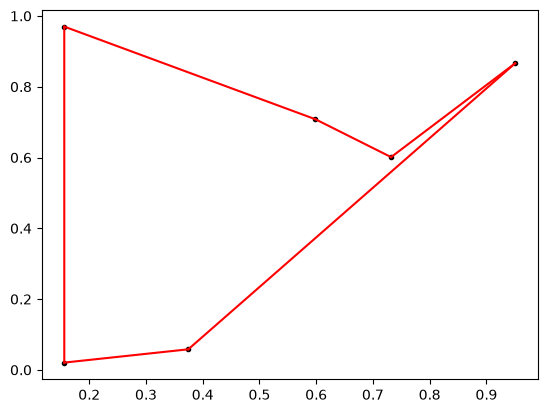

t=0 c=np.float64(3.6164334487439125)
t=3 c=np.float64(3.6115791899859193)
t=4 c=np.float64(3.3486730535350886)
t=7 c=np.float64(3.221030003949177)
final cost c=np.float64(3.221030003949177)


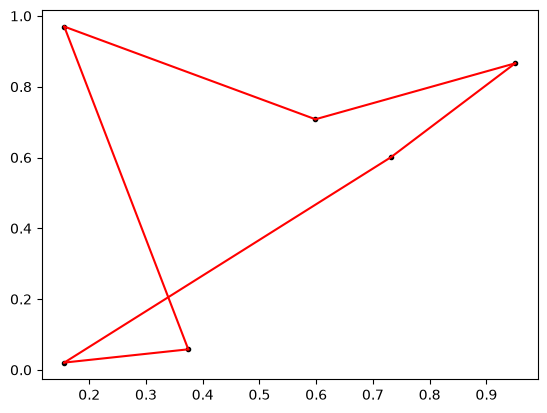

t=1 c=np.float64(3.1794835557724688)
t=4 c=np.float64(3.0650452272857494)
final cost c=np.float64(3.0650452272857494)


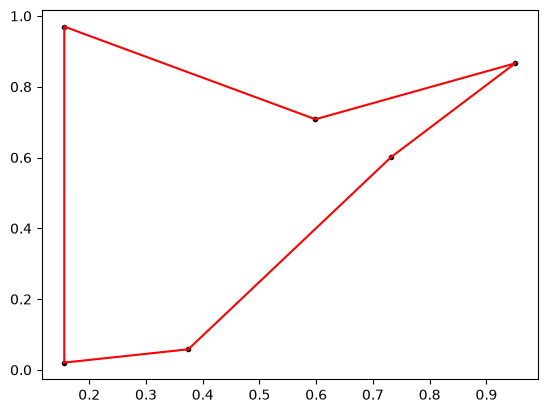

best cost c=3.0650452272857494


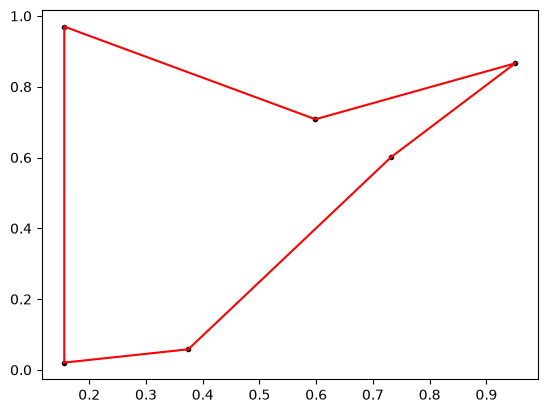

array([4, 0, 2, 1, 3, 5], dtype=int32)

In [14]:
def greedy(probl: TSP, max_iters=10, seed=None, restarts=1):
    if seed is not None:
        np.random.seed(seed)

    best_c = np.inf
    best_x = None

    for r in range(restarts):
        x = probl.init_config()
        c = probl.cost(x)

        for t in range(max_iters):
            y = probl.propose_move(x)

            delta_c = probl.delta_cost(x, y)

            if delta_c <= 0:
                x = y
                c += delta_c

                print(f"{t=} {c=}")

        print(f"final cost {c=}")
        probl.display(x)

        if c < best_c:
            best_c = c
            best_x = x

    print(f"best cost c={best_c}")
    probl.display(best_x)

    return best_x


greedy(probl, restarts=3)

In [15]:
p = TSP(4, seed=42)

p.x = np.array([0.0, 1.0, 1.0, 0.0])
p.y = np.array([0.0, 0.0, 1.0, 1.0])

old_route = np.array([0, 2, 1, 3])
new_route = np.array([0, 1, 2, 3])

print(p.cost(old_route))
print(p.cost(new_route))
print(p.delta_cost(old_route, new_route))

4.82842712474619
4.0
-0.8284271247461898


t=0 c=np.float64(4.861985763413282)
t=3 c=np.float64(4.7619623578046415)
t=4 c=np.float64(4.694261279722751)
t=5 c=np.float64(3.973742074773253)
t=8 c=np.float64(3.9222147977182473)
t=11 c=np.float64(3.9151859727852316)
t=13 c=np.float64(3.1364199274259392)
t=14 c=np.float64(3.0757476742770646)
t=29 c=np.float64(3.0752099246922397)
t=65 c=np.float64(2.9377788886981353)
t=98 c=np.float64(2.8333672258073115)
final cost c=np.float64(2.8333672258073115)


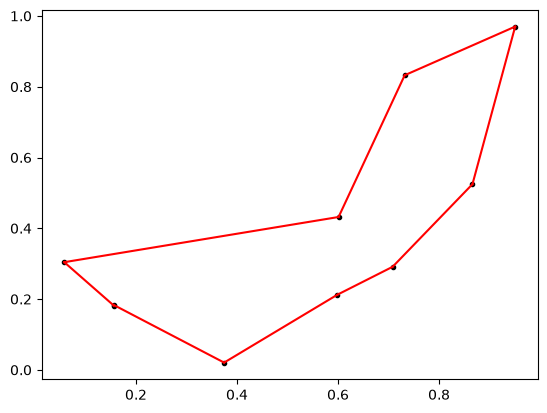

t=0 c=np.float64(4.512919400238533)
t=2 c=np.float64(4.452231374369706)
t=9 c=np.float64(4.427224177909854)
t=11 c=np.float64(4.010282721012602)
t=15 c=np.float64(3.754362819772451)
t=16 c=np.float64(3.714257520714053)
t=17 c=np.float64(3.351653988378721)
t=23 c=np.float64(3.1793295419412373)
t=24 c=np.float64(3.1177576755611915)
t=49 c=np.float64(2.9525955809442075)
t=62 c=np.float64(2.950389979665401)
t=68 c=np.float64(2.8837961784354706)
final cost c=np.float64(2.8837961784354706)


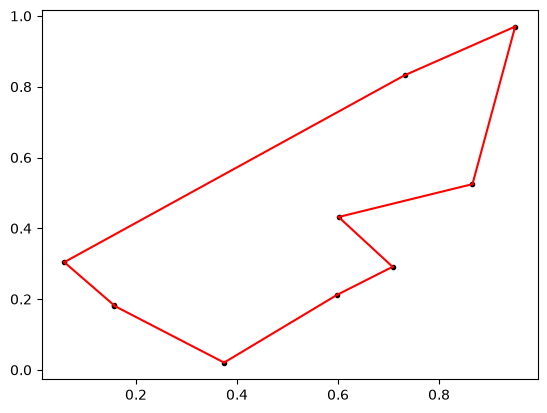

t=7 c=np.float64(4.465452123210065)
t=11 c=np.float64(4.432669792741123)
t=18 c=np.float64(3.9146482232004067)
t=19 c=np.float64(3.1358821778411143)
t=30 c=np.float64(3.1358027556310684)
t=31 c=np.float64(2.96969993737457)
final cost c=np.float64(2.96969993737457)


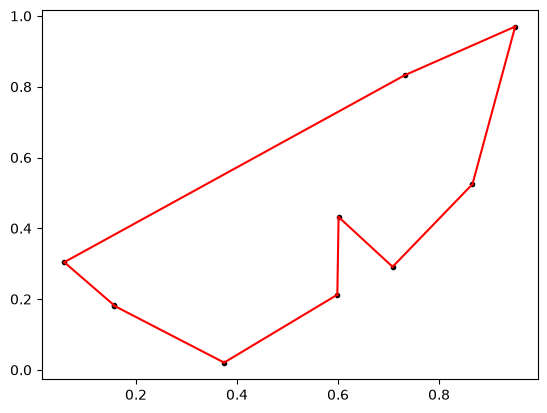

best cost c=2.8333672258073115


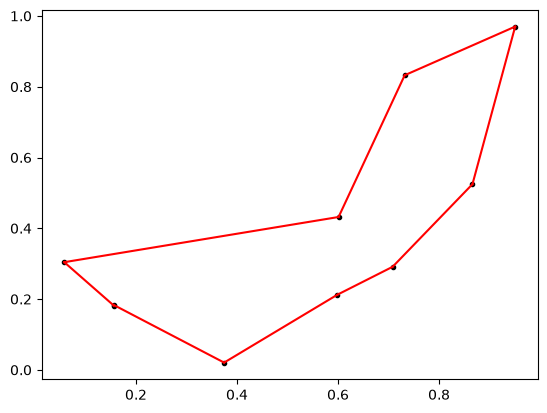

[2 1 7 9 3 0 5 4 6 8]
2.8333672258073115


In [16]:
pt = TSP(10, seed=42)

best_route = greedy(
    pt,
    max_iters=100,
    seed=1,
    restarts=3
)

print(best_route)
print(pt.cost(best_route))

t=0 c=np.float64(2.152782920586496)
t=1 c=np.float64(1.9977472859085985)
final cost c=np.float64(1.9977472859085985)


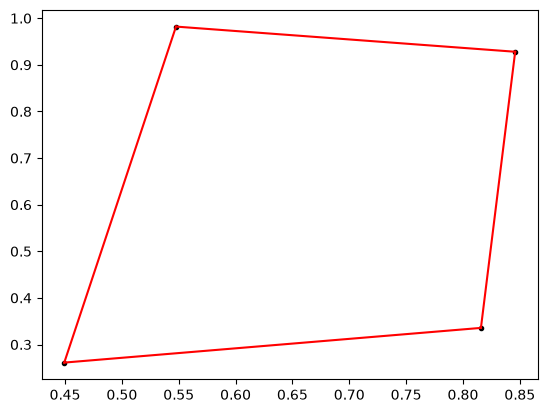

t=6 c=np.float64(1.9977472859085985)
final cost c=np.float64(1.9977472859085985)


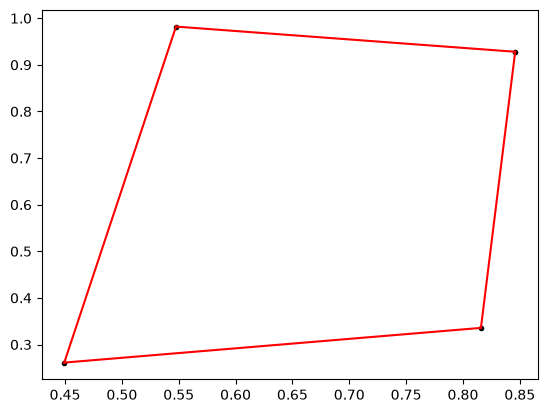

final cost c=np.float64(1.9977472859085985)


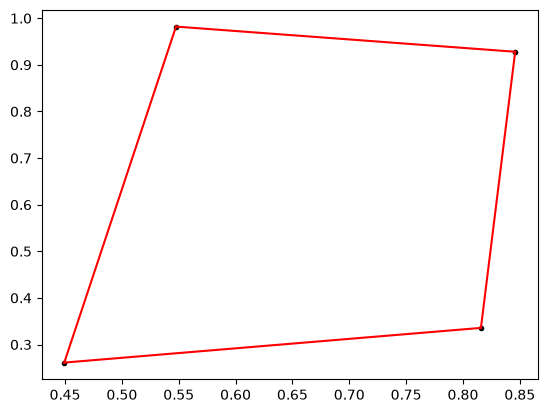

best cost c=1.9977472859085985


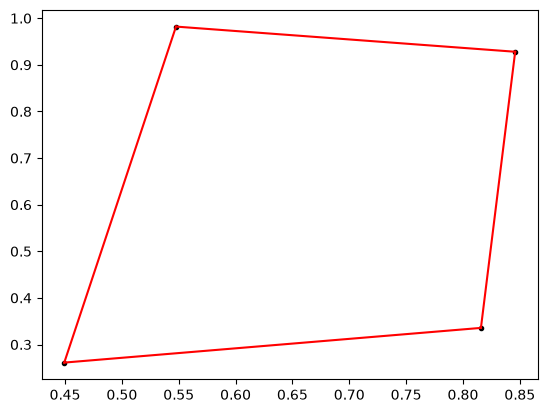

(array([3, 2, 1, 0]), np.float64(1.9977472859085985))

In [17]:
# greedy v5
from copy import deepcopy


class TSP:
    def __init__(self, n, seed=None):
        if not (isinstance(n, int) and n > 3):
            raise Exception("n needs to be an integer larger than 3")

        if seed is not None:
            np.random.seed(seed)

        self.n = n

        x = np.random.rand(n)
        y = np.random.rand(n)

        self.x, self.y = x, y

        self.route = np.arange(n)
        self.init_config()  # optional

    def dist(self, city0, city1):
        x, y = self.x, self.y

        x0, y0 = x[city0], y[city0]
        x1, y1 = x[city1], y[city1]

        return np.sqrt((x1 - x0)**2 + (y1 - y0)**2)

    def __repr__(self) -> str:
        return f"TSP with {self.n} cities"

    def init_config(self):
        self.route[:] = np.random.permutation(self.n)  # route

    def display(self):
        x, y, n, route = self.x, self.y, self.n, self.route

        plt.clf()

        plt.plot(x, y, '.', color="black")

        for e in range(n):
            city0 = route[e]
            city1 = route[(e+1) % n]

            plt.plot(
                [x[city0], x[city1]],
                [y[city0], y[city1]],
                color="red"
            )

        plt.pause(0.01)

    def cost(self):
        n, route = self.n, self.route

        c = 0.0

        for e in range(n):
            city0 = route[e]
            city1 = route[(e + 1) % n]

            c += self.dist(city0, city1)

        return c

    def copy(self):
        return deepcopy(self)

    def delta_cost(self, move):
        c_old = self.cost()

        new_tsp = self.copy()
        new_tsp.accept_move(move)

        c_new = new_tsp.cost()

        return c_new - c_old  # delta_c

    def propose_move(self):
        n = self.n

        while True:
            e1 = np.random.randint(n)
            e2 = np.random.randint(n)

            if e1 > e2:
                e1, e2 = e2, e1

            if e1 != e2 and e1 + 1 != e2 and not (e1 == 0 and e2 == n-1):
                break

        return (e1, e2)  # move

    def accept_move(self, move):
        route = self.route
        e1, e2 = move
        route[e1+1:e2+1] = route[e2:e1:-1]


def greedy(probl: TSP, max_iters=10, seed=None, restarts=1):

    if not isinstance(restarts, int) or restarts < 1:
        raise ValueError("restarts must be an integer >= 1")

    if not isinstance(max_iters, int) or max_iters < 0:
        raise ValueError("max_iters must be an integer >= 0")

    if seed is not None:
        np.random.seed(seed)

    best_c = np.inf
    best_probl = None

    for r in range(restarts):
        probl.init_config()
        c = probl.cost()

        for t in range(max_iters):
            move = probl.propose_move()

            delta_c = probl.delta_cost(move)

            if delta_c <= 0:
                probl.accept_move(move)
                c += delta_c

                print(f"{t=} {c=}")

        print(f"final cost {c=}")
        probl.display()

        if c < best_c:
            best_c = c
            best_probl = probl.copy()

    print(f"best cost c={best_c}")
    best_probl.display()

    return best_probl


probl = TSP(4)
best = greedy(probl, restarts=3)

best.route, best.cost()

In [18]:
class T:
    def __init__(self, n):
        self.r = np.arange(n)

    def m(self):
        self.r[:] = np.random.permutation(len(self.r))


t = T(4)

a = t.r
print(a)

t.m()

b = t.r
print(b)

print(a is b)

[0 1 2 3]
[3 1 0 2]
True


t=0 c=np.float64(3.588875902176763)
t=3 c=np.float64(3.36338343376117)
t=4 c=np.float64(3.30231563705571)
t=6 c=np.float64(2.6025541042619804)
final cost c=np.float64(2.6025541042619813)


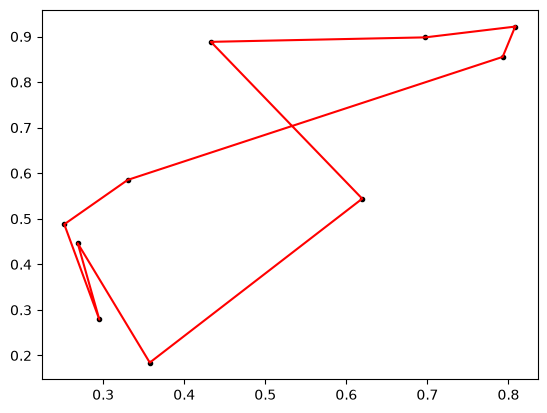

t=1 c=np.float64(4.596442788516122)
t=5 c=np.float64(4.438274940524049)
final cost c=np.float64(4.438274940524049)


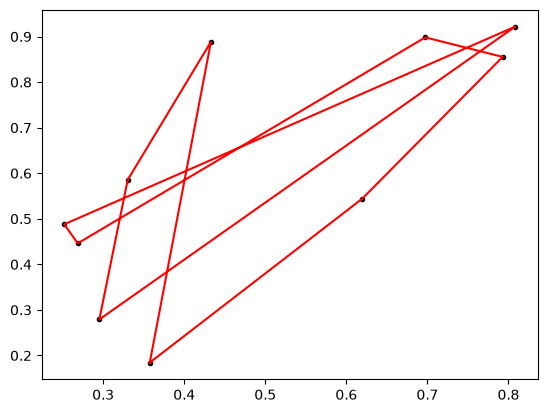

t=1 c=np.float64(5.341602664407304)
t=2 c=np.float64(4.80569464944849)
t=5 c=np.float64(4.498184639085469)
t=7 c=np.float64(4.020695784707474)
t=9 c=np.float64(3.8074900952888653)
final cost c=np.float64(3.807490095288865)


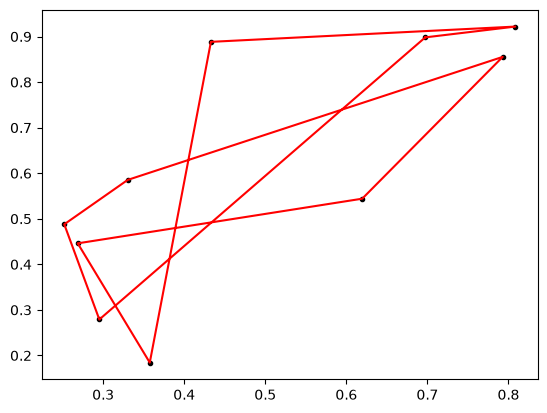

t=1 c=np.float64(3.5655920769312557)
t=6 c=np.float64(3.5572615625421995)
t=8 c=np.float64(2.516829236975127)
final cost c=np.float64(2.516829236975127)


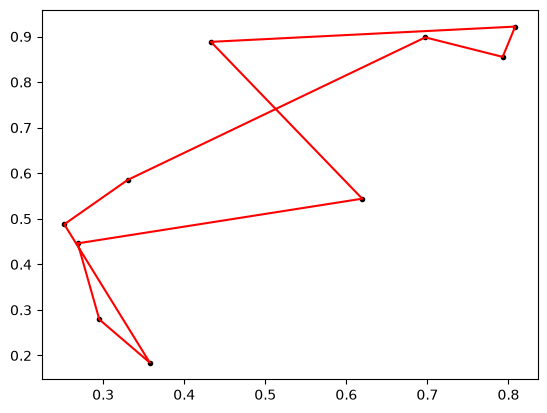

best cost c=2.516829236975127


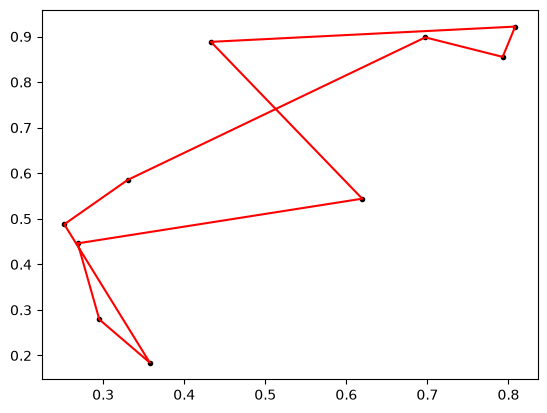

(array([7, 9, 4, 1, 5, 6, 2, 8, 3, 0]), np.float64(2.516829236975127))

In [19]:
# greedy v6
class TSP:
    def __init__(self, n, seed=None):
        if not (isinstance(n, int) and n > 3):
            raise Exception("n needs to be an integer larger than 3")

        if seed is not None:
            np.random.seed(seed)

        self.n = n

        x = np.random.rand(n)
        y = np.random.rand(n)

        self.x, self.y = x, y

        self.route = np.arange(n)
        self.init_config()  # optional

    def dist(self, city0, city1):
        x, y = self.x, self.y

        x0, y0 = x[city0], y[city0]
        x1, y1 = x[city1], y[city1]

        return np.sqrt((x1 - x0)**2 + (y1 - y0)**2)

    def __repr__(self) -> str:
        return f"TSP with {self.n} cities"

    def init_config(self):
        self.route[:] = np.random.permutation(self.n)  # route

    def display(self):
        x, y, n, route = self.x, self.y, self.n, self.route

        plt.clf()

        plt.plot(x, y, '.', color="black")

        # for e in range(n):
        #     city0 = route[e]
        #     city1 = route[(e+1) % n]

        #     plt.plot(
        #         [x[city0], x[city1]],
        #         [y[city0], y[city1]],
        #         color="red"
        #     )
        # <=>
        positions = np.arange(n+1) % n
        closed_route = route[positions]

        plt.plot(
            x[closed_route],
            y[closed_route],
            color="red"
        )

        plt.pause(0.01)

    def cost(self):
        n, route = self.n, self.route

        c = 0.0

        for e in range(n):
            city0 = route[e]
            city1 = route[(e + 1) % n]

            c += self.dist(city0, city1)

        return c

    def copy(self):
        return deepcopy(self)

    def delta_cost(self, move):
        route, n = self.route, self.n
        e1, e2 = move

        i = route[e1]
        j = route[e1 + 1]

        l = route[e2]
        k = route[(e2 + 1) % n]

        old_c = self.dist(i, j) + self.dist(l, k)
        new_c = self.dist(i, l) + self.dist(j, k)

        return new_c - old_c

    def propose_move(self):
        n = self.n

        while True:
            e1 = np.random.randint(n)
            e2 = np.random.randint(n)

            if e1 > e2:
                e1, e2 = e2, e1

            if e1 != e2 and e1 + 1 != e2 and not (e1 == 0 and e2 == n-1):
                break

        return (e1, e2)  # move

    def accept_move(self, move):
        route = self.route
        e1, e2 = move
        route[e1+1:e2+1] = route[e2:e1:-1]


def greedy(probl: TSP, max_iters=10, seed=None, restarts=1):

    if not isinstance(restarts, int) or restarts < 1:
        raise ValueError("restarts must be an integer >= 1")

    if not isinstance(max_iters, int) or max_iters < 0:
        raise ValueError("max_iters must be an integer >= 0")

    if seed is not None:
        np.random.seed(seed)

    best_c = np.inf
    best_probl = None

    for r in range(restarts):
        probl.init_config()
        c = probl.cost()

        for t in range(max_iters):
            move = probl.propose_move()

            delta_c = probl.delta_cost(move)

            if delta_c <= 0:
                probl.accept_move(move)
                c += delta_c

                print(f"{t=} {c=}")

        c = probl.cost()

        print(f"final cost {c=}")
        probl.display()

        if c < best_c:
            best_c = c
            best_probl = probl.copy()

    print(f"best cost c={best_c}")
    best_probl.display()

    return best_probl


probl = TSP(10)
best = greedy(probl, restarts=4)

best.route, best.cost()

t=0 c=np.float64(49.39897521798352)
t=1 c=np.float64(49.35727550625372)
t=5 c=np.float64(48.346450667222136)
t=9 c=np.float64(48.20442807765143)
t=13 c=np.float64(47.801661597700644)
t=15 c=np.float64(47.79325451451956)
t=16 c=np.float64(47.719287489656466)
t=17 c=np.float64(47.5524575304341)
t=18 c=np.float64(46.87634048531415)
t=20 c=np.float64(46.81362979644713)
t=21 c=np.float64(46.73646221885051)
t=22 c=np.float64(46.65610391133476)
t=24 c=np.float64(46.64327873455147)
t=25 c=np.float64(46.19281987701511)
t=26 c=np.float64(45.91250435800011)
t=31 c=np.float64(45.86140659196092)
t=34 c=np.float64(45.52721949446356)
t=36 c=np.float64(45.34079708758009)
t=37 c=np.float64(45.31307985285326)
t=38 c=np.float64(45.216050944854636)
t=40 c=np.float64(44.59715225315726)
t=42 c=np.float64(44.27781676584274)
t=44 c=np.float64(43.75997502730864)
t=47 c=np.float64(43.69241051353042)
t=49 c=np.float64(43.07242922813737)
t=52 c=np.float64(42.288655585922285)
t=54 c=np.float64(42.27228649390616)
t

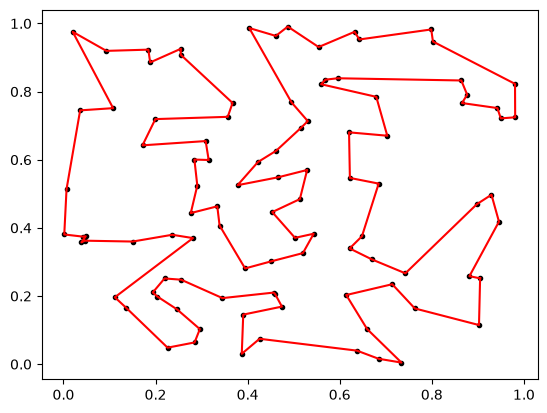

t=0 c=np.float64(51.67656038798245)
t=3 c=np.float64(50.65614617208168)
t=6 c=np.float64(50.61250112245484)
t=7 c=np.float64(50.473321799573846)
t=8 c=np.float64(50.169939941378665)
t=9 c=np.float64(50.06772655441522)
t=10 c=np.float64(49.12238578113806)
t=15 c=np.float64(48.75136192559935)
t=18 c=np.float64(48.72792419161919)
t=21 c=np.float64(48.65852671075234)
t=23 c=np.float64(48.3779264086228)
t=25 c=np.float64(47.90223401024672)
t=27 c=np.float64(47.7957104208636)
t=28 c=np.float64(47.53187398862625)
t=31 c=np.float64(46.88045016958262)
t=33 c=np.float64(46.49928284876719)
t=35 c=np.float64(46.356709864101894)
t=40 c=np.float64(46.33197749960665)
t=41 c=np.float64(46.173132528760505)
t=42 c=np.float64(45.527251328767534)
t=47 c=np.float64(45.171375065242096)
t=48 c=np.float64(44.86200341218388)
t=49 c=np.float64(44.45463281431626)
t=51 c=np.float64(44.20923174793088)
t=53 c=np.float64(43.283989079639234)
t=56 c=np.float64(43.05813487476573)
t=57 c=np.float64(42.64621559454682)
t=

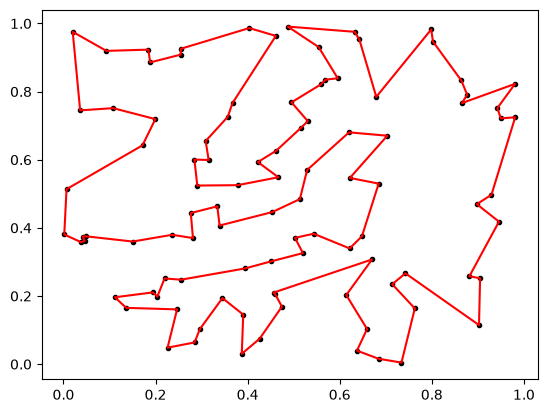

t=0 c=np.float64(45.18872319547408)
t=1 c=np.float64(45.0587772411175)
t=2 c=np.float64(44.71495626434192)
t=3 c=np.float64(44.68843627186598)
t=18 c=np.float64(44.17045805784143)
t=19 c=np.float64(43.51343611068572)
t=22 c=np.float64(43.264820077524725)
t=23 c=np.float64(43.20924722919476)
t=25 c=np.float64(42.898611146136986)
t=26 c=np.float64(42.74672781084257)
t=31 c=np.float64(42.58584525763288)
t=35 c=np.float64(42.52757232071581)
t=36 c=np.float64(41.13082735604953)
t=40 c=np.float64(40.66709648932318)
t=43 c=np.float64(40.40823578860924)
t=46 c=np.float64(40.383616685657955)
t=54 c=np.float64(40.240123909311336)
t=56 c=np.float64(39.75619760695996)
t=57 c=np.float64(39.693837841115844)
t=63 c=np.float64(39.51935241025121)
t=76 c=np.float64(39.36565093745325)
t=77 c=np.float64(38.757878387870306)
t=81 c=np.float64(38.342007225791505)
t=82 c=np.float64(38.034115141169224)
t=83 c=np.float64(37.7263510760929)
t=85 c=np.float64(37.714555313471244)
t=90 c=np.float64(37.55288945181066

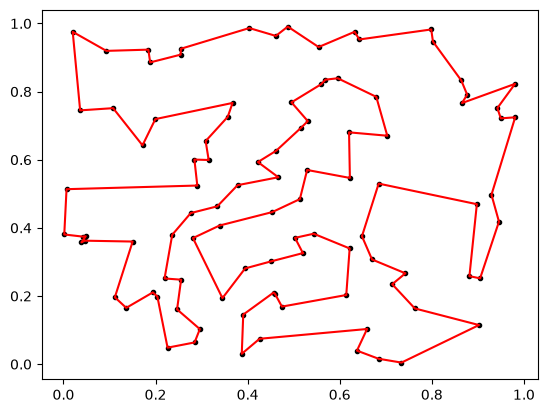

t=0 c=np.float64(48.97350044694463)
t=2 c=np.float64(48.969726433462846)
t=5 c=np.float64(48.72130259336878)
t=8 c=np.float64(48.33030141055356)
t=9 c=np.float64(47.881821639944036)
t=12 c=np.float64(47.72843409764079)
t=14 c=np.float64(47.525986833312324)
t=16 c=np.float64(47.37579976683057)
t=19 c=np.float64(47.35955394170411)
t=20 c=np.float64(47.30075098388049)
t=21 c=np.float64(47.1308308452385)
t=23 c=np.float64(46.544902692562744)
t=25 c=np.float64(46.46219677574929)
t=28 c=np.float64(46.045513760405)
t=32 c=np.float64(46.008481447042165)
t=35 c=np.float64(45.830460658896826)
t=39 c=np.float64(45.750747337304745)
t=40 c=np.float64(45.48672234725359)
t=43 c=np.float64(45.45083716132655)
t=44 c=np.float64(45.14974538467053)
t=45 c=np.float64(45.034361273426036)
t=49 c=np.float64(44.68616985974349)
t=53 c=np.float64(44.20217743598537)
t=56 c=np.float64(43.935289846451354)
t=61 c=np.float64(43.78020729862167)
t=63 c=np.float64(43.72273210526397)
t=65 c=np.float64(43.31912457830696)


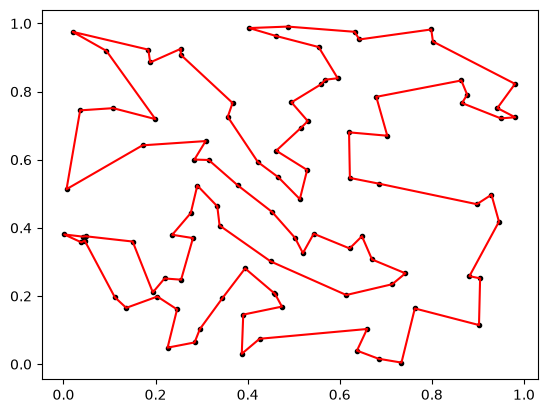

t=3 c=np.float64(44.654881291047694)
t=4 c=np.float64(44.03479837851985)
t=10 c=np.float64(43.337058021992384)
t=13 c=np.float64(42.7881341136487)
t=16 c=np.float64(42.732080372903)
t=22 c=np.float64(42.30763796228392)
t=24 c=np.float64(42.15245969204045)
t=27 c=np.float64(41.696446093991604)
t=29 c=np.float64(41.688748614820774)
t=32 c=np.float64(41.5726159797854)
t=36 c=np.float64(41.50701466955673)
t=37 c=np.float64(41.372108345069385)
t=43 c=np.float64(41.3261349639486)
t=44 c=np.float64(41.13090885612495)
t=51 c=np.float64(40.91668205964307)
t=56 c=np.float64(40.54641812235627)
t=57 c=np.float64(40.52447160200035)
t=60 c=np.float64(40.379820617509836)
t=62 c=np.float64(40.29706715802386)
t=63 c=np.float64(39.99304911058292)
t=68 c=np.float64(39.934450651197636)
t=69 c=np.float64(39.86961212458348)
t=70 c=np.float64(39.18314459334037)
t=77 c=np.float64(38.53511304596709)
t=83 c=np.float64(38.14204498792659)
t=85 c=np.float64(37.877700459930935)
t=86 c=np.float64(37.6154627342547)
t

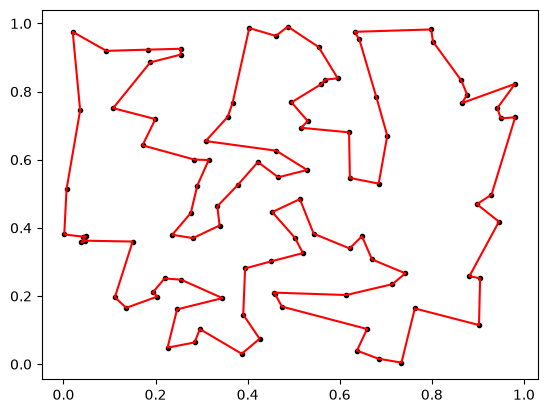

best cost c=8.474764266325984


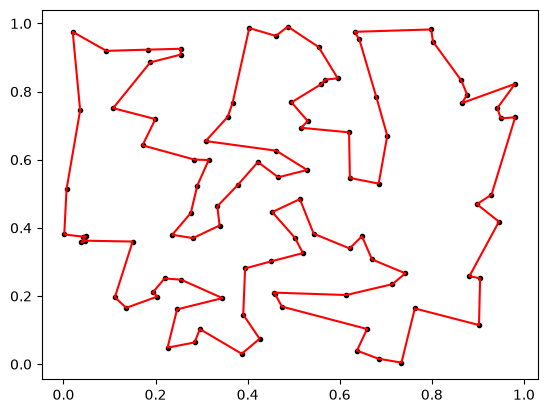

(array([67, 87, 32, 45, 28, 43, 90, 12, 71, 72, 56, 61, 17, 47, 25, 24, 98,
        60, 75, 99, 74, 80, 55, 20, 27, 84, 23, 95, 50,  9,  2, 46, 33, 52,
        63, 73, 86, 59,  1, 10,  4, 42, 81, 83,  8,  5, 97, 41, 44, 38,  0,
        62, 76, 29, 85,  3, 40, 36, 21, 31, 79, 77, 78, 51, 19, 13, 66, 11,
        64, 58, 91, 39, 26, 65, 16, 37,  7, 93, 53, 82, 15, 57, 69, 48, 49,
        92, 34, 68, 35,  6, 94, 88, 18, 14, 54, 30, 70, 96, 22, 89]),
 np.float64(8.474764266325984))

In [20]:
# greedy v7
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy


class TSP:
    def __init__(self, n, seed=None):
        if not (isinstance(n, int) and n > 3):
            raise ValueError("n needs to be an integer larger than 3")

        if seed is not None:
            np.random.seed(seed)

        self.n = n

        x = np.random.rand(n)
        y = np.random.rand(n)

        self.x, self.y = x, y

        xT = x.reshape((n, 1))
        yT = y.reshape((n, 1))

        self.dist = np.sqrt((x - xT)**2 + (y - yT)**2)

        self.route = np.arange(n)
        self.init_config()  # optional

    def __repr__(self) -> str:
        return f"TSP with {self.n} cities"

    def init_config(self):
        self.route[:] = np.random.permutation(self.n)  # route

    def display(self):
        x, y, n, route = self.x, self.y, self.n, self.route

        plt.clf()

        plt.plot(x, y, '.', color="black")

        positions = np.arange(n+1) % n
        closed_route = route[positions]

        plt.plot(
            x[closed_route],
            y[closed_route],
            color="red"
        )

        plt.pause(0.01)

    def cost(self):
        n, route = self.n, self.route

        c = 0.0

        for e in range(n):
            city0 = route[e]
            city1 = route[(e + 1) % n]

            c += self.dist[city0, city1]

        return c

    def copy(self):
        return deepcopy(self)

    def delta_cost(self, move):
        route, n = self.route, self.n
        e1, e2 = move

        i = route[e1]
        j = route[e1 + 1]

        l = route[e2]
        k = route[(e2 + 1) % n]

        old_c = self.dist[i, j] + self.dist[l, k]
        new_c = self.dist[i, l] + self.dist[j, k]

        return new_c - old_c

    def propose_move(self):
        n = self.n

        while True:
            e1 = np.random.randint(n)
            e2 = np.random.randint(n)

            if e1 > e2:
                e1, e2 = e2, e1

            if e1 != e2 and e1 + 1 != e2 and not (e1 == 0 and e2 == n-1):
                break

        return (e1, e2)  # move

    def accept_move(self, move):
        route = self.route
        e1, e2 = move
        route[e1+1:e2+1] = route[e2:e1:-1]


def greedy(probl: TSP, max_iters=10, seed=None, restarts=1):

    if not isinstance(restarts, int) or restarts < 1:
        raise ValueError("restarts must be an integer >= 1")

    if not isinstance(max_iters, int) or max_iters < 0:
        raise ValueError("max_iters must be an integer >= 0")

    if seed is not None:
        np.random.seed(seed)

    best_c = np.inf
    best_probl = None

    for r in range(restarts):
        probl.init_config()
        c = probl.cost()

        for t in range(max_iters):
            move = probl.propose_move()

            delta_c = probl.delta_cost(move)

            if delta_c <= 0:
                probl.accept_move(move)
                c += delta_c

                print(f"{t=} {c=}")

        c = probl.cost()

        print(f"final cost {c=}")
        probl.display()

        if c < best_c:
            best_c = c
            best_probl = probl.copy()

    print(f"best cost c={best_c}")
    best_probl.display()

    return best_probl


probl = TSP(100, seed=123376)
best = greedy(probl, restarts=5, max_iters=50000)

best.route, best.cost()

In [21]:
x = np.array([0, 3, 0, 3])
y = np.array([0, 0, 4, 4])

x.shape

(4,)

In [22]:
xt = x.reshape((4, 1))
xt

array([[0],
       [3],
       [0],
       [3]])

In [23]:
yt = y.reshape((4, 1))
yt

array([[0],
       [0],
       [4],
       [4]])

In [24]:
""" 
0 1 2 3
-------
0 3 0 3        0 0 0 0 | row 0 = x - x[0]
0 3 0 3    -   3 3 3 3 |     1 = x - x[1]
0 3 0 3        0 0 0 0 |     2 = x - x[2]
0 3 0 3        3 3 3 3 |     3 = x - x[3]
"""
x - xt

array([[ 0,  3,  0,  3],
       [-3,  0, -3,  0],
       [ 0,  3,  0,  3],
       [-3,  0, -3,  0]])

t=0 c=np.float64(49.39897521798352)
t=1 c=np.float64(49.35727550625372)
t=5 c=np.float64(48.346450667222136)
t=9 c=np.float64(48.20442807765143)
t=13 c=np.float64(47.801661597700644)
t=15 c=np.float64(47.79325451451956)
t=16 c=np.float64(47.719287489656466)
t=17 c=np.float64(47.5524575304341)
t=18 c=np.float64(46.87634048531415)
t=20 c=np.float64(46.81362979644713)
t=21 c=np.float64(46.73646221885051)
t=22 c=np.float64(46.65610391133476)
t=24 c=np.float64(46.64327873455147)
t=25 c=np.float64(46.19281987701511)
t=26 c=np.float64(45.91250435800011)
t=31 c=np.float64(45.86140659196092)
t=34 c=np.float64(45.52721949446356)
t=36 c=np.float64(45.34079708758009)
t=37 c=np.float64(45.31307985285326)
t=38 c=np.float64(45.216050944854636)
t=40 c=np.float64(44.59715225315726)
t=42 c=np.float64(44.27781676584274)
t=44 c=np.float64(43.75997502730864)
t=47 c=np.float64(43.69241051353042)
t=49 c=np.float64(43.07242922813737)
t=52 c=np.float64(42.288655585922285)
t=54 c=np.float64(42.27228649390616)
t

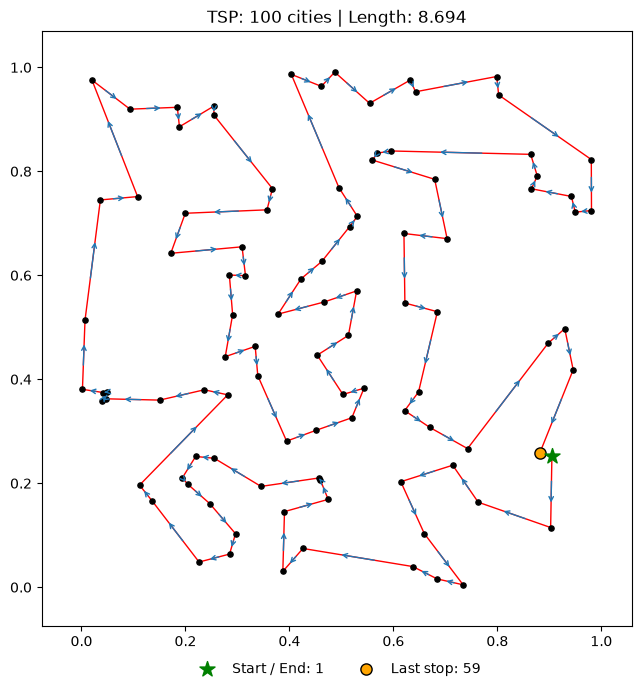

t=0 c=np.float64(51.67656038798245)
t=3 c=np.float64(50.65614617208168)
t=6 c=np.float64(50.61250112245484)
t=7 c=np.float64(50.473321799573846)
t=8 c=np.float64(50.169939941378665)
t=9 c=np.float64(50.06772655441522)
t=10 c=np.float64(49.12238578113806)
t=15 c=np.float64(48.75136192559935)
t=18 c=np.float64(48.72792419161919)
t=21 c=np.float64(48.65852671075234)
t=23 c=np.float64(48.3779264086228)
t=25 c=np.float64(47.90223401024672)
t=27 c=np.float64(47.7957104208636)
t=28 c=np.float64(47.53187398862625)
t=31 c=np.float64(46.88045016958262)
t=33 c=np.float64(46.49928284876719)
t=35 c=np.float64(46.356709864101894)
t=40 c=np.float64(46.33197749960665)
t=41 c=np.float64(46.173132528760505)
t=42 c=np.float64(45.527251328767534)
t=47 c=np.float64(45.171375065242096)
t=48 c=np.float64(44.86200341218388)
t=49 c=np.float64(44.45463281431626)
t=51 c=np.float64(44.20923174793088)
t=53 c=np.float64(43.283989079639234)
t=56 c=np.float64(43.05813487476573)
t=57 c=np.float64(42.64621559454682)
t=

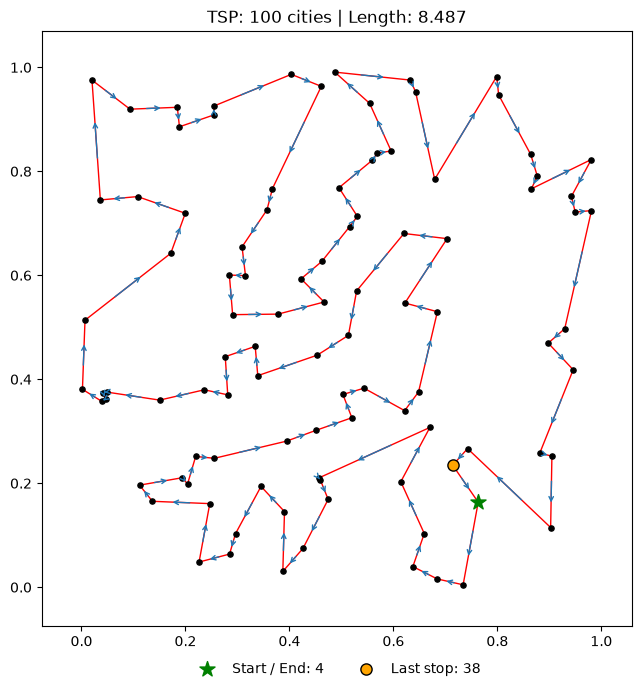

t=0 c=np.float64(45.18872319547408)
t=1 c=np.float64(45.0587772411175)
t=2 c=np.float64(44.71495626434192)
t=3 c=np.float64(44.68843627186598)
t=18 c=np.float64(44.17045805784143)
t=19 c=np.float64(43.51343611068572)
t=22 c=np.float64(43.264820077524725)
t=23 c=np.float64(43.20924722919476)
t=25 c=np.float64(42.898611146136986)
t=26 c=np.float64(42.74672781084257)
t=31 c=np.float64(42.58584525763288)
t=35 c=np.float64(42.52757232071581)
t=36 c=np.float64(41.13082735604953)
t=40 c=np.float64(40.66709648932318)
t=43 c=np.float64(40.40823578860924)
t=46 c=np.float64(40.383616685657955)
t=54 c=np.float64(40.240123909311336)
t=56 c=np.float64(39.75619760695996)
t=57 c=np.float64(39.693837841115844)
t=63 c=np.float64(39.51935241025121)
t=76 c=np.float64(39.36565093745325)
t=77 c=np.float64(38.757878387870306)
t=81 c=np.float64(38.342007225791505)
t=82 c=np.float64(38.034115141169224)
t=83 c=np.float64(37.7263510760929)
t=85 c=np.float64(37.714555313471244)
t=90 c=np.float64(37.55288945181066

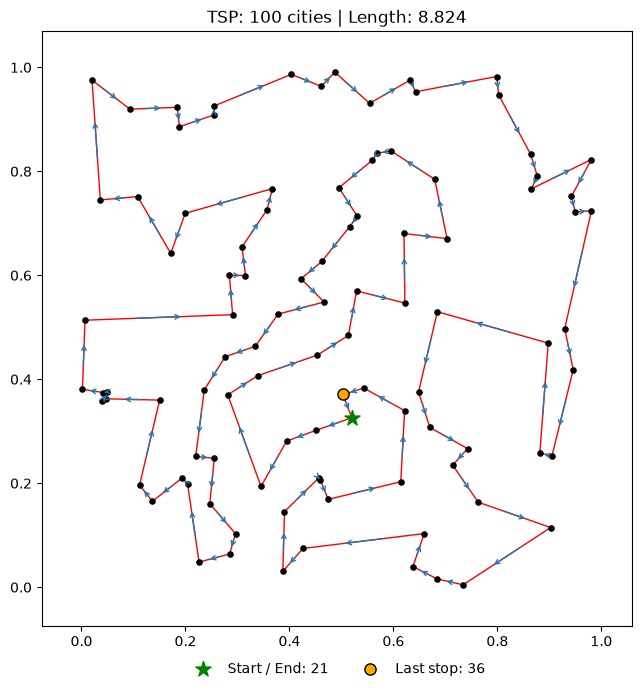

t=0 c=np.float64(48.97350044694463)
t=2 c=np.float64(48.969726433462846)
t=5 c=np.float64(48.72130259336878)
t=8 c=np.float64(48.33030141055356)
t=9 c=np.float64(47.881821639944036)
t=12 c=np.float64(47.72843409764079)
t=14 c=np.float64(47.525986833312324)
t=16 c=np.float64(47.37579976683057)
t=19 c=np.float64(47.35955394170411)
t=20 c=np.float64(47.30075098388049)
t=21 c=np.float64(47.1308308452385)
t=23 c=np.float64(46.544902692562744)
t=25 c=np.float64(46.46219677574929)
t=28 c=np.float64(46.045513760405)
t=32 c=np.float64(46.008481447042165)
t=35 c=np.float64(45.830460658896826)
t=39 c=np.float64(45.750747337304745)
t=40 c=np.float64(45.48672234725359)
t=43 c=np.float64(45.45083716132655)
t=44 c=np.float64(45.14974538467053)
t=45 c=np.float64(45.034361273426036)
t=49 c=np.float64(44.68616985974349)
t=53 c=np.float64(44.20217743598537)
t=56 c=np.float64(43.935289846451354)
t=61 c=np.float64(43.78020729862167)
t=63 c=np.float64(43.72273210526397)
t=65 c=np.float64(43.31912457830696)


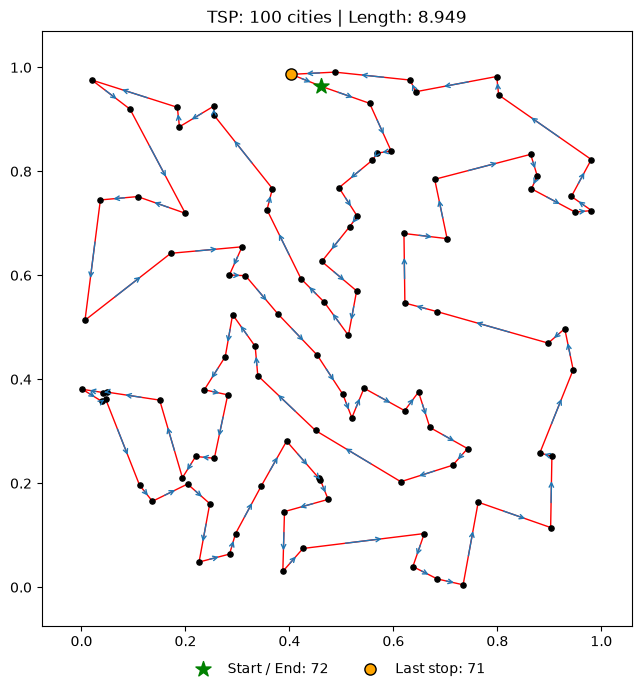

t=3 c=np.float64(44.654881291047694)
t=4 c=np.float64(44.03479837851985)
t=10 c=np.float64(43.337058021992384)
t=13 c=np.float64(42.7881341136487)
t=16 c=np.float64(42.732080372903)
t=22 c=np.float64(42.30763796228392)
t=24 c=np.float64(42.15245969204045)
t=27 c=np.float64(41.696446093991604)
t=29 c=np.float64(41.688748614820774)
t=32 c=np.float64(41.5726159797854)
t=36 c=np.float64(41.50701466955673)
t=37 c=np.float64(41.372108345069385)
t=43 c=np.float64(41.3261349639486)
t=44 c=np.float64(41.13090885612495)
t=51 c=np.float64(40.91668205964307)
t=56 c=np.float64(40.54641812235627)
t=57 c=np.float64(40.52447160200035)
t=60 c=np.float64(40.379820617509836)
t=62 c=np.float64(40.29706715802386)
t=63 c=np.float64(39.99304911058292)
t=68 c=np.float64(39.934450651197636)
t=69 c=np.float64(39.86961212458348)
t=70 c=np.float64(39.18314459334037)
t=77 c=np.float64(38.53511304596709)
t=83 c=np.float64(38.14204498792659)
t=85 c=np.float64(37.877700459930935)
t=86 c=np.float64(37.6154627342547)
t

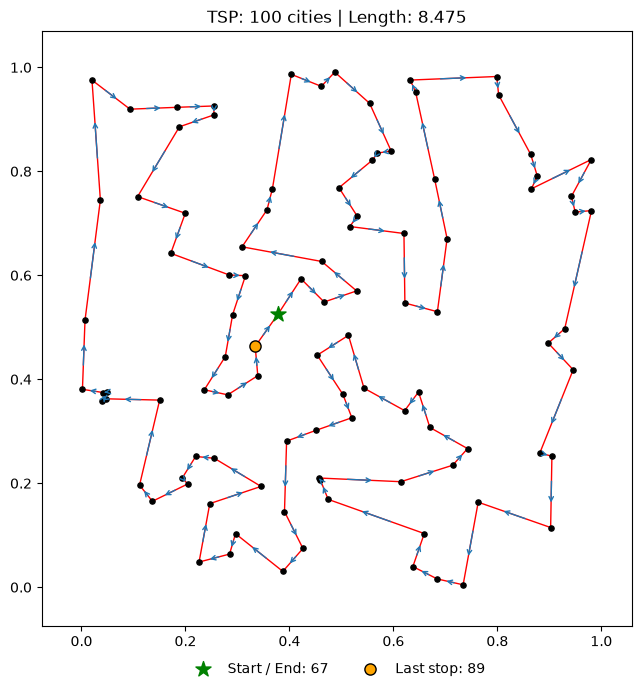

best cost c=8.474764266325984


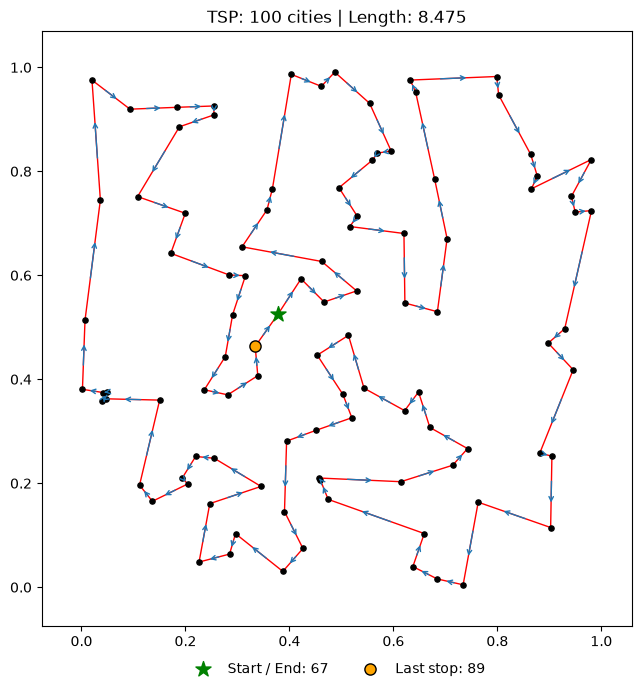

(array([67, 87, 32, 45, 28, 43, 90, 12, 71, 72, 56, 61, 17, 47, 25, 24, 98,
        60, 75, 99, 74, 80, 55, 20, 27, 84, 23, 95, 50,  9,  2, 46, 33, 52,
        63, 73, 86, 59,  1, 10,  4, 42, 81, 83,  8,  5, 97, 41, 44, 38,  0,
        62, 76, 29, 85,  3, 40, 36, 21, 31, 79, 77, 78, 51, 19, 13, 66, 11,
        64, 58, 91, 39, 26, 65, 16, 37,  7, 93, 53, 82, 15, 57, 69, 48, 49,
        92, 34, 68, 35,  6, 94, 88, 18, 14, 54, 30, 70, 96, 22, 89]),
 np.float64(8.474764266325984))

In [25]:
# greedy v8
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy


class TSP:
    def __init__(self, n, seed=None):
        if not (isinstance(n, int) and n > 3):
            raise ValueError("n needs to be an integer larger than 3")

        if seed is not None:
            np.random.seed(seed)

        self.n = n

        x = np.random.rand(n)
        y = np.random.rand(n)

        self.x, self.y = x, y

        xT = x.reshape((n, 1))
        yT = y.reshape((n, 1))

        self.dist = np.sqrt((x - xT)**2 + (y - yT)**2)

        self.route = np.arange(n)
        self.init_config()  # optional

    def __repr__(self) -> str:
        return f"TSP with {self.n} cities"

    def init_config(self):
        self.route[:] = np.random.permutation(self.n)  # route

    def display(self):
        x, y, n, route = self.x, self.y, self.n, self.route

        # Tạo hình có tên "TSP" để nhiều lần gọi display sử dụng lại một cửa sổ để vẽ lên
        plt.figure("TSP", figsize=(8, 7)) # width: 8 inch, height: 7 inch
        plt.clf() # xóa lộ trình cũ để vẽ lộ trình mới

        closed_route = np.append(route, route[0])


        plt.plot(
            x[closed_route],
            y[closed_route],
            color="red", linewidth=1
        )

        plt.scatter(x, y, s=14, color="black", zorder=3) # s - diện tích dấu chấm, tăng lên thì lớn hơn

        step = max(1, n//15)
        step = 1
        
        for e in range(0, n, step):
            a = route[e]
            b = route[(e + 1) % n]
        
            dx = x[b] - x[a]
            dy = y[b] - y[a]
        
            plt.annotate(
                "",
                xy=(x[a] + 0.65 * dx, y[a] + 0.65 * dy),
                xytext=(x[a] + 0.35 * dx, y[a] + 0.35 * dy),
                arrowprops=dict(
                    arrowstyle="->",
                    color="tab:blue",
                    linewidth=1,
                    mutation_scale=8,
                    shrinkA=0,
                    shrinkB=0
                )
            )

        start, last = route[0], route[-1]

        plt.scatter(
            x[start], y[start],
            s=130, marker="*",
            color="green",
            zorder=5,
            label=f"Start / End: {start}"
        )

        plt.scatter(
            x[last], y[last],
            s=65,
            color="orange",
            edgecolors="black",
            zorder=4,
            label=f"Last stop: {last}"
        )

        plt.title(f"TSP: {n} cities | Length: {self.cost():.3f}")

        plt.gca().set_aspect("equal", adjustable="box")
        plt.margins(0.08)

        plt.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, -0.04),
            ncol=2,
            frameon=False
        )
        plt.tight_layout()


        plt.pause(0.01)

    def cost(self):
        n, route = self.n, self.route

        c = 0.0

        for e in range(n):
            city0 = route[e]
            city1 = route[(e + 1) % n]

            c += self.dist[city0, city1]

        return c

    def copy(self):
        return deepcopy(self)

    def delta_cost(self, move):
        route, n = self.route, self.n
        e1, e2 = move

        i = route[e1]
        j = route[e1 + 1]

        l = route[e2]
        k = route[(e2 + 1) % n]

        old_c = self.dist[i, j] + self.dist[l, k]
        new_c = self.dist[i, l] + self.dist[j, k]

        return new_c - old_c

    def propose_move(self):
        n = self.n

        while True:
            e1 = np.random.randint(n)
            e2 = np.random.randint(n)

            if e1 > e2:
                e1, e2 = e2, e1

            if e1 != e2 and e1 + 1 != e2 and not (e1 == 0 and e2 == n-1):
                break

        return (e1, e2)  # move

    def accept_move(self, move):
        route = self.route
        e1, e2 = move
        route[e1+1:e2+1] = route[e2:e1:-1]


def greedy(probl: TSP, max_iters=10, seed=None, restarts=1):

    if not isinstance(restarts, int) or restarts < 1:
        raise ValueError("restarts must be an integer >= 1")

    if not isinstance(max_iters, int) or max_iters < 0:
        raise ValueError("max_iters must be an integer >= 0")

    if seed is not None:
        np.random.seed(seed)

    best_c = np.inf
    best_probl = None

    for r in range(restarts):
        probl.init_config()
        c = probl.cost()

        for t in range(max_iters):
            move = probl.propose_move()

            delta_c = probl.delta_cost(move)

            if delta_c <= 0:
                probl.accept_move(move)
                c += delta_c

                print(f"{t=} {c=}")

        c = probl.cost()

        print(f"final cost {c=}")
        probl.display()

        if c < best_c:
            best_c = c
            best_probl = probl.copy()

    print(f"best cost c={best_c}")
    best_probl.display()

    return best_probl


probl = TSP(100, seed=123376)
best = greedy(probl, restarts=5, max_iters=50000)

best.route, best.cost()